In [13]:
from tensorflow.keras.datasets import imdb

In [14]:
import numpy as np
import pandas as pd

#Problem Statement

A movie streaming company wants to automatically analyze customer reviews and determine whether a review is:
- Positive
- Negative

The company currently receives thousands of reviews daily and manual analysis is impossible.

As an AI Engineer, your task is to build and compare three Deep Learning models:
- SimpleRNN
- LSTM
- GRU

Then identify which architecture performs best for sentiment analysis.

Project Objectives

Build an end-to-end NLP application that:
- processes movie reviews
- trains three sequence models
- compares performance
- deploys the best model using Streamlit

###Task 1: Dataset Analysis
Perform exploratory analysis:
- Number of reviews
- Positive reviews count
- Negative reviews count
- Average review length
- Longest review
- Shortest review

In [15]:
from tensorflow.keras.datasets import imdb

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

reviews = list(X_train) + list(X_test)
labels = list(y_train) + list(y_test)

print("Total Reviews:", len(reviews))
print("Positive Reviews:", labels.count(1))
print("Negative Reviews:", labels.count(0))

lengths = []

for review in reviews:
    lengths.append(len(review))

print("Average Review Length:", round(sum(lengths) / len(lengths), 2))
print("Longest Review:", max(lengths))
print("Shortest Review:", min(lengths))

Total Reviews: 50000
Positive Reviews: 25000
Negative Reviews: 25000
Average Review Length: 234.76
Longest Review: 2494
Shortest Review: 7


# ***Task 2: Text Preprocessing***
Apply:

- Lowercase conversion
- HTML tag removal
- Punctuation removal
- Stopword removal
- Tokenization
- Sequence generation
- Padding

In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import nltk
from nltk.corpus import stopwords
import re
import string

nltk.download('stopwords')

word_index = imdb.get_word_index()

reverse_word_index = {}

for word, index in word_index.items():
    reverse_word_index[index + 3] = word

reviews_text = []

for review in reviews:
    text = ""

    for num in review:
        text += reverse_word_index.get(num, "") + " "

    reviews_text.append(text)

stop_words = stopwords.words("english")

clean_reviews = []

for review in reviews_text:
    review = review.lower()
    review = re.sub(r"<.*?>", "", review)
    review = review.translate(str.maketrans("", "", string.punctuation))

    words = review.split()

    filtered_words = []

    for word in words:
        if word not in stop_words:
            filtered_words.append(word)

    clean_reviews.append(filtered_words)

X_train = pad_sequences(X_train, maxlen=200)
X_test = pad_sequences(X_test, maxlen=200)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## ***Task 3: Build SimpleRNN Model***

Architecture:

    Embedding Layer
          ↓
      SimpleRNN
          ↓
      Dense Layer
          ↓
    Output Layer

Train and evaluate the model.

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

rnn_model = Sequential()

rnn_model.add(Embedding(input_dim=10000, output_dim=32, input_length=200))
rnn_model.add(SimpleRNN(32))
rnn_model.add(Dense(16, activation="relu"))
rnn_model.add(Dense(1, activation="sigmoid"))

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

start = time.time()

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

rnn_time = round(time.time() - start, 2)

y_pred = rnn_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

rnn_accuracy = accuracy_score(y_test, y_pred)
rnn_precision = precision_score(y_test, y_pred)
rnn_recall = recall_score(y_test, y_pred)
rnn_f1 = f1_score(y_test, y_pred)

rnn_val_accuracy = history_rnn.history["val_accuracy"][-1]
rnn_val_loss = history_rnn.history["val_loss"][-1]

rnn_params = rnn_model.count_params()

print("Accuracy:", rnn_accuracy)
print("Precision:", rnn_precision)
print("Recall:", rnn_recall)
print("F1 Score:", rnn_f1)
print("Training Time:", rnn_time)
print("Validation Accuracy:", rnn_val_accuracy)
print("Validation Loss:", rnn_val_loss)
print("Number of Parameters:", rnn_params)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.6696 - loss: 0.5893 - val_accuracy: 0.7968 - val_loss: 0.4544
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8587 - loss: 0.3383 - val_accuracy: 0.8246 - val_loss: 0.3914
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9194 - loss: 0.2085 - val_accuracy: 0.8390 - val_loss: 0.4027
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9651 - loss: 0.1040 - val_accuracy: 0.8380 - val_loss: 0.5037
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9792 - loss: 0.0601 - val_accuracy: 0.7874 - val_loss: 0.6658
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
Accuracy: 0.78728
Precision: 0.8141182645206438
Recall: 0.74456
F1 Score: 0.7777870633461474
Training Time: 38.4
Validation Accuracy: 0.7874000072479248
Validation Loss: 0.6657623052597046
Number of Parameters: 322625


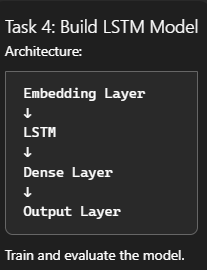

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential()

lstm_model.add(Embedding(input_dim=10000, output_dim=32, input_length=200))
lstm_model.add(LSTM(32))
lstm_model.add(Dense(16, activation="relu"))
lstm_model.add(Dense(1, activation="sigmoid"))

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

start = time.time()

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

lstm_time = round(time.time() - start, 2)

y_pred = lstm_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

lstm_accuracy = accuracy_score(y_test, y_pred)
lstm_precision = precision_score(y_test, y_pred)
lstm_recall = recall_score(y_test, y_pred)
lstm_f1 = f1_score(y_test, y_pred)

lstm_val_accuracy = history_lstm.history["val_accuracy"][-1]
lstm_val_loss = history_lstm.history["val_loss"][-1]

lstm_params = lstm_model.count_params()

print("Accuracy:", lstm_accuracy)
print("Precision:", lstm_precision)
print("Recall:", lstm_recall)
print("F1 Score:", lstm_f1)
print("Training Time:", lstm_time)
print("Validation Accuracy:", lstm_val_accuracy)
print("Validation Loss:", lstm_val_loss)
print("Number of Parameters:", lstm_params)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7651 - loss: 0.4550 - val_accuracy: 0.8568 - val_loss: 0.3424
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9044 - loss: 0.2460 - val_accuracy: 0.8708 - val_loss: 0.3105
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9281 - loss: 0.1885 - val_accuracy: 0.8752 - val_loss: 0.3163
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9428 - loss: 0.1519 - val_accuracy: 0.8706 - val_loss: 0.3344
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9595 - loss: 0.1154 - val_accuracy: 0.8644 - val_loss: 0.4123
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
Accuracy: 0.84752
Precision: 0.8983128553090042
Recall: 0.78376
F1 Score: 0.8371357771511578
Training Time: 23.88
Validation Accuracy: 0.8644000291824341
Validation Loss: 0.4122765064239502
Number of Parameters: 328865


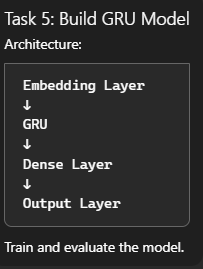

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

gru_model = Sequential()

gru_model.add(Embedding(input_dim=10000, output_dim=32, input_length=200))
gru_model.add(GRU(32))
gru_model.add(Dense(16, activation="relu"))
gru_model.add(Dense(1, activation="sigmoid"))

gru_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

start = time.time()

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

gru_time = round(time.time() - start, 2)

y_pred = gru_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

gru_accuracy = accuracy_score(y_test, y_pred)
gru_precision = precision_score(y_test, y_pred)
gru_recall = recall_score(y_test, y_pred)
gru_f1 = f1_score(y_test, y_pred)

gru_val_accuracy = history_gru.history["val_accuracy"][-1]
gru_val_loss = history_gru.history["val_loss"][-1]

gru_params = gru_model.count_params()

print("Accuracy:", gru_accuracy)
print("Precision:", gru_precision)
print("Recall:", gru_recall)
print("F1 Score:", gru_f1)
print("Training Time:", gru_time)
print("Validation Accuracy:", gru_val_accuracy)
print("Validation Loss:", gru_val_loss)
print("Number of Parameters:", gru_params)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7361 - loss: 0.4984 - val_accuracy: 0.8580 - val_loss: 0.3376
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8925 - loss: 0.2679 - val_accuracy: 0.8580 - val_loss: 0.3406
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9251 - loss: 0.1988 - val_accuracy: 0.8408 - val_loss: 0.4020
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9431 - loss: 0.1545 - val_accuracy: 0.8676 - val_loss: 0.3330
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9588 - loss: 0.1159 - val_accuracy: 0.8600 - val_loss: 0.3845
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
Accuracy: 0.84956
Precision: 0.8987861640960116
Recall: 0.78784
F1 Score: 0.8396640661636185
Training Time: 23.9
Validation Accuracy: 0.8600000143051147
Validation Loss: 0.3845343291759491
Number of Parameters: 326881


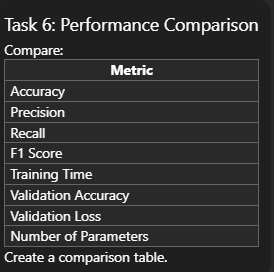

In [25]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time",
        "Validation Accuracy",
        "Validation Loss",
        "Number of Parameters"
    ],
    "SimpleRNN": [
        rnn_accuracy,
        rnn_precision,
        rnn_recall,
        rnn_f1,
        rnn_time,
        rnn_val_accuracy,
        rnn_val_loss,
        rnn_params
    ],
    "LSTM": [
        lstm_accuracy,
        lstm_precision,
        lstm_recall,
        lstm_f1,
        lstm_time,
        lstm_val_accuracy,
        lstm_val_loss,
        lstm_params
    ],
    "GRU": [
        gru_accuracy,
        gru_precision,
        gru_recall,
        gru_f1,
        gru_time,
        gru_val_accuracy,
        gru_val_loss,
        gru_params
    ]
})

print(comparison)

                 Metric      SimpleRNN           LSTM            GRU
0              Accuracy       0.787280       0.847520       0.849560
1             Precision       0.814118       0.898313       0.898786
2                Recall       0.744560       0.783760       0.787840
3              F1 Score       0.777787       0.837136       0.839664
4         Training Time      38.400000      23.880000      23.900000
5   Validation Accuracy       0.787400       0.864400       0.860000
6       Validation Loss       0.665762       0.412277       0.384534
7  Number of Parameters  322625.000000  328865.000000  326881.000000


In [26]:
if lstm_accuracy >= rnn_accuracy and lstm_accuracy >= gru_accuracy:
    print("Best Model: LSTM")
elif gru_accuracy >= rnn_accuracy and gru_accuracy >= lstm_accuracy:
    print("Best Model: GRU")
else:
    print("Best Model: SimpleRNN")

Best Model: GRU


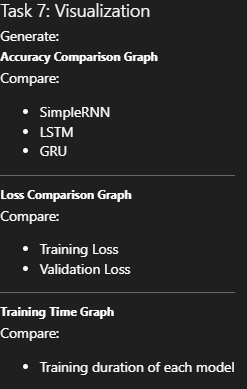

### ***Accuracy Graph , Loss Graph , Training Time Graph***

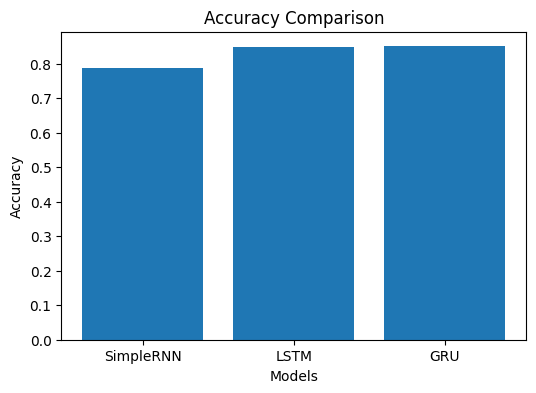

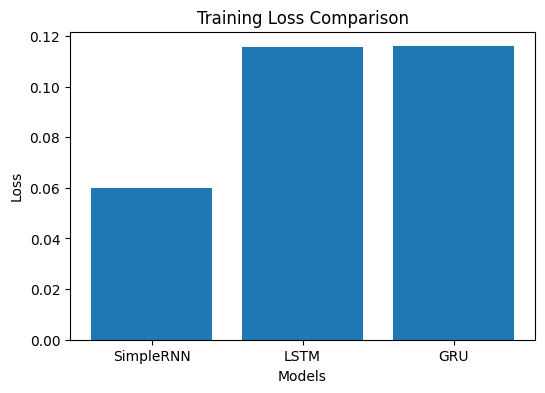

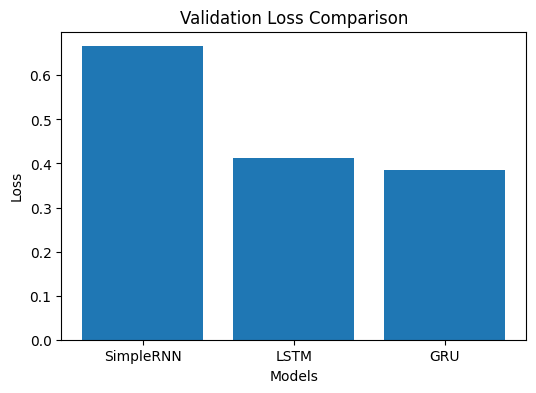

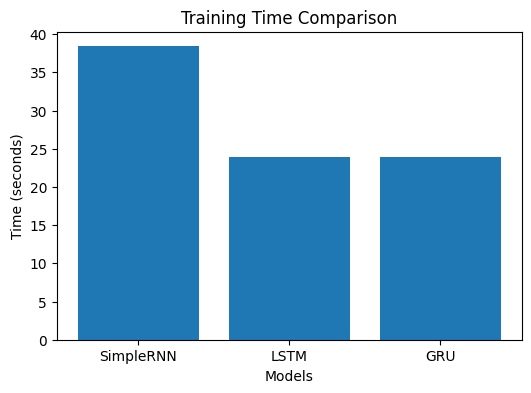

In [29]:
import matplotlib.pyplot as plt

models = ["SimpleRNN", "LSTM", "GRU"]

accuracy = [rnn_accuracy, lstm_accuracy, gru_accuracy]

training_loss = [
    history_rnn.history["loss"][-1],
    history_lstm.history["loss"][-1],
    history_gru.history["loss"][-1]
]

validation_loss = [
    rnn_val_loss,
    lstm_val_loss,
    gru_val_loss
]

training_time = [rnn_time, lstm_time, gru_time]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracy)
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(models, training_loss, label="Training Loss")
plt.title("Training Loss Comparison")
plt.xlabel("Models")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(models, validation_loss, label="Validation Loss")
plt.title("Validation Loss Comparison")
plt.xlabel("Models")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(models, training_time)
plt.title("Training Time Comparison")
plt.xlabel("Models")
plt.ylabel("Time (seconds)")
plt.show()

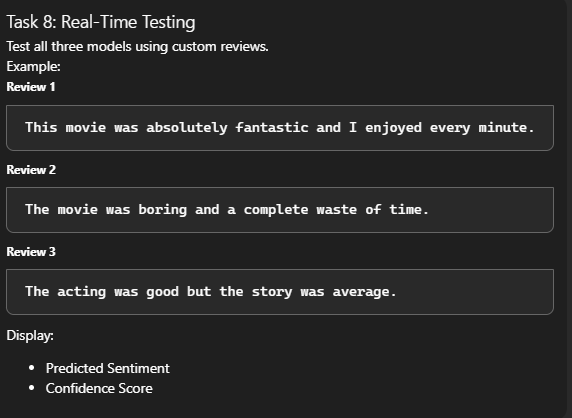

In [30]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

reviews = [
    "This movie was absolutely fantastic and I enjoyed every minute.",
    "The movie was boring and a complete waste of time.",
    "The acting was good but the story was average."
]

word_index = imdb.get_word_index()

for review in reviews:

    words = review.lower().split()

    sequence = []

    for word in words:
        if word in word_index:
            sequence.append(word_index[word] + 3)

    padded = pad_sequences([sequence], maxlen=200)

    rnn_pred = rnn_model.predict(padded, verbose=0)[0][0]
    lstm_pred = lstm_model.predict(padded, verbose=0)[0][0]
    gru_pred = gru_model.predict(padded, verbose=0)[0][0]

    print("\nReview:", review)

    print("SimpleRNN:")
    print("Sentiment:", "Positive" if rnn_pred > 0.5 else "Negative")
    print("Confidence Score:", round(float(rnn_pred), 4))

    print("\nLSTM:")
    print("Sentiment:", "Positive" if lstm_pred > 0.5 else "Negative")
    print("Confidence Score:", round(float(lstm_pred), 4))

    print("\nGRU:")
    print("Sentiment:", "Positive" if gru_pred > 0.5 else "Negative")
    print("Confidence Score:", round(float(gru_pred), 4))


Review: This movie was absolutely fantastic and I enjoyed every minute.
SimpleRNN:
Sentiment: Negative
Confidence Score: 0.4882

LSTM:
Sentiment: Positive
Confidence Score: 0.8399

GRU:
Sentiment: Positive
Confidence Score: 0.888

Review: The movie was boring and a complete waste of time.
SimpleRNN:
Sentiment: Negative
Confidence Score: 0.005

LSTM:
Sentiment: Negative
Confidence Score: 0.0103

GRU:
Sentiment: Negative
Confidence Score: 0.0089

Review: The acting was good but the story was average.
SimpleRNN:
Sentiment: Negative
Confidence Score: 0.0124

LSTM:
Sentiment: Positive
Confidence Score: 0.519

GRU:
Sentiment: Positive
Confidence Score: 0.5655


## ***Task 9: Model Analysis Report***

You must answer:
- Question 1

    - Which model achieved the highest accuracy?
    - ans. GRU
- Question 2
  - Which model trained fastest?
  - ans. GRU

- Question 3
  - Why did LSTM outperform SimpleRNN?
  - ans. STM outperformed SimpleRNN because it retains long-term information better and avoids the vanishing gradient problem.

- Question 4
  - Why does GRU train faster than LSTM?
  - ans. Due to less gates in GRU

- Question 5
  - If the dataset grows to 1 million reviews, which model would you choose and why?
  - ans. I will choose the GRU because of less training time and best accuracy